<a href="https://colab.research.google.com/github/RiznoFadhil/cinema-ticket-analysis/blob/main/cinema_ticket_sales_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# PROYEK: Cinema Ticket Customer Segmentation & Retention Analysis
# Tools: Python (pandas, scikit-learn)
# Dijalankan di Google Colab
# =========================================================

In [ ]:
# -----------------------------------------------------
# STEP 0 - Install & Import Library
# -----------------------------------------------------
!pip install scikit-learn pandas -q

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
# -----------------------------------------------------
# STEP 1 - Upload Dataset
# -----------------------------------------------------
# Upload file 'cinema_hall_ticket_sales.csv' dari komputer kamu
from google.colab import files
uploaded = files.upload()

# Ambil nama file yang baru diupload secara otomatis
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Jumlah baris & kolom:", df.shape)
df.head()

Saving cinema_hall_ticket_sales.csv to cinema_hall_ticket_sales.csv
Jumlah baris & kolom: (1440, 7)


,Ticket_ID,Age,Ticket_Price,Movie_Genre,Seat_Type,Number_of_Person,Purchase_Again
0,N4369,55,12.27,Comedy,Standard,7,No
1,B8091,35,19.02,Drama,Standard,Alone,Yes
2,V6341,55,22.52,Horror,VIP,3,No
3,B3243,53,23.01,Drama,Standard,6,Yes
4,I3814,30,21.81,Comedy,VIP,4,Yes


In [ ]:
# -----------------------------------------------------
# STEP 2 - Data Cleaning
# -----------------------------------------------------

# 2a. Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())

# 2b. Bersihkan kolom 'Number_of_Person' (campuran teks & angka)
# -> pisah jadi 'group_size' (numerik) dan 'attendance_type' (kategori)
df['group_size'] = df['Number_of_Person'].replace('Alone', '1').astype(int)
df['attendance_type'] = df['group_size'].apply(
    lambda x: 'Alone' if x == 1 else 'Group'
)

# 2c. Cek & tangani Ticket_ID yang duplikat
n_dupes = df['Ticket_ID'].duplicated().sum()
print(f"\nJumlah Ticket_ID duplikat: {n_dupes}")

# Setelah dicek, isi barisnya berbeda (bukan transaksi ganda),
# jadi ID dibuat unik dengan menambahkan suffix, data tidak dihapus
dup_mask = df['Ticket_ID'].duplicated(keep=False)
df.loc[dup_mask, 'Ticket_ID'] = (
    df.loc[dup_mask, 'Ticket_ID']
    + '_'
    + df.loc[dup_mask].groupby('Ticket_ID').cumcount().astype(str)
)

print("Jumlah Ticket_ID unik setelah cleaning:", df['Ticket_ID'].nunique())

Missing values per kolom:
Ticket_ID           0
Age                 0
Ticket_Price        0
Movie_Genre         0
Seat_Type           0
Number_of_Person    0
Purchase_Again      0
dtype: int64

Jumlah Ticket_ID duplikat: 4
Jumlah Ticket_ID unik setelah cleaning: 1440


In [ ]:
# -----------------------------------------------------
# STEP 3 - Feature Engineering untuk Clustering
# -----------------------------------------------------

# Encoding ordinal untuk Seat_Type (Standard < Premium < VIP)
seat_map = {'Standard': 1, 'Premium': 2, 'VIP': 3}
df['seat_rank'] = df['Seat_Type'].map(seat_map)

# Ubah target retensi jadi biner (0/1) untuk kebutuhan analisis lanjutan
df['purchase_again_bin'] = (df['Purchase_Again'] == 'Yes').astype(int)

# Fitur yang dipakai untuk clustering
features = ['Age', 'Ticket_Price', 'seat_rank', 'group_size']
X = df[features].copy()

# Standardisasi fitur (penting karena skala tiap fitur berbeda-beda)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k=2 | inertia=4542.9 | silhouette=0.226
k=3 | inertia=3787.8 | silhouette=0.206
k=4 | inertia=3280.5 | silhouette=0.208
k=5 | inertia=2869.4 | silhouette=0.220
k=6 | inertia=2562.4 | silhouette=0.228
k=7 | inertia=2312.5 | silhouette=0.233


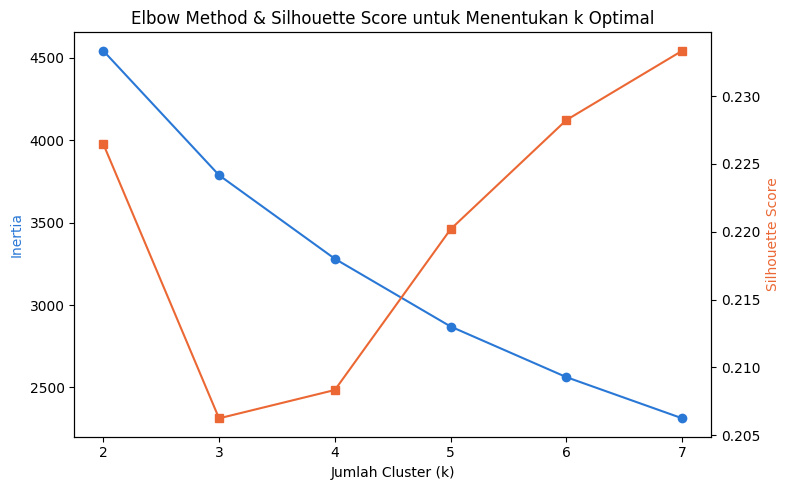

In [ ]:
# -----------------------------------------------------
# STEP 4 - Menentukan Jumlah Cluster Optimal (k)
# -----------------------------------------------------

inertia_list = []
silhouette_list = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))
    print(f"k={k} | inertia={km.inertia_:.1f} | silhouette={silhouette_score(X_scaled, labels):.3f}")

# Visualisasi Elbow Method
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(list(k_range), inertia_list, marker='o', color='#2a78d6', label='Inertia')
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Inertia', color='#2a78d6')

ax2 = ax1.twinx()
ax2.plot(list(k_range), silhouette_list, marker='s', color='#eb6834', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='#eb6834')

plt.title('Elbow Method & Silhouette Score untuk Menentukan k Optimal')
fig.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------
# STEP 5 - Fit K-Means dengan k=4
# -----------------------------------------------------
# k=4 dipilih dengan mempertimbangkan trade-off antara skor statistik
# dan kebutuhan bisnis (cukup granular untuk dibuat persona, tapi
# tetap mudah diinterpretasi)

k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nJumlah pelanggan per cluster:")
print(df['cluster'].value_counts().sort_index())


Jumlah pelanggan per cluster:
cluster
0    394
1    368
2    384
3    294
Name: count, dtype: int64


In [ ]:
# -----------------------------------------------------
# STEP 6 - Profiling & Interpretasi Cluster
# -----------------------------------------------------

profile = df.groupby('cluster').agg(
    n=('Ticket_ID', 'count'),
    avg_age=('Age', 'mean'),
    avg_price=('Ticket_Price', 'mean'),
    avg_seat_rank=('seat_rank', 'mean'),
    avg_group_size=('group_size', 'mean'),
    retention_pct=('purchase_again_bin', lambda x: round(100 * x.mean(), 1)),
).round(2)

print("\nProfil tiap cluster:")
print(profile)

print("\nKarakteristik dominan tiap cluster:")
for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    print(
        f"Cluster {c}: genre favorit = {sub['Movie_Genre'].mode()[0]}, "
        f"seat favorit = {sub['Seat_Type'].mode()[0]}, "
        f"attendance favorit = {sub['attendance_type'].mode()[0]}"
    )


Profil tiap cluster:
           n  avg_age  avg_price  avg_seat_rank  avg_group_size  retention_pct
cluster                                                                       
0        394    36.52      17.44           2.18            5.94           47.5
1        368    49.02      17.71           2.58            1.75           49.7
2        384    26.13      17.31           2.08            1.45           46.9
3        294    46.13      17.01           1.00            2.08           53.4

Karakteristik dominan tiap cluster:
Cluster 0: genre favorit = Drama, seat favorit = VIP, attendance favorit = Group
Cluster 1: genre favorit = Action, seat favorit = VIP, attendance favorit = Alone
Cluster 2: genre favorit = Sci-Fi, seat favorit = Premium, attendance favorit = Alone
Cluster 3: genre favorit = Action, seat favorit = Standard, attendance favorit = Alone


In [ ]:
# -----------------------------------------------------
# STEP 7 - Pemberian Nama Persona
# -----------------------------------------------------
# Nama persona disesuaikan dengan hasil profiling di atas.
# PENTING: urutan cluster (0,1,2,3) bisa berbeda setiap run karena
# inisialisasi KMeans bersifat acak (meski random_state sudah di-set,
# urutan label cluster tetap bisa berubah tergantung versi library).
# Cek ulang tabel 'profile' di atas sebelum mapping nama di bawah ini.

persona_map = {
    0: 'Family/Group VIP Moviegoers',
    1: 'Mature Action Enthusiast',
    2: 'Young Sci-Fi Solo-goer',
    3: 'Budget Standard Loyalist',
}
df['persona'] = df['cluster'].map(persona_map)

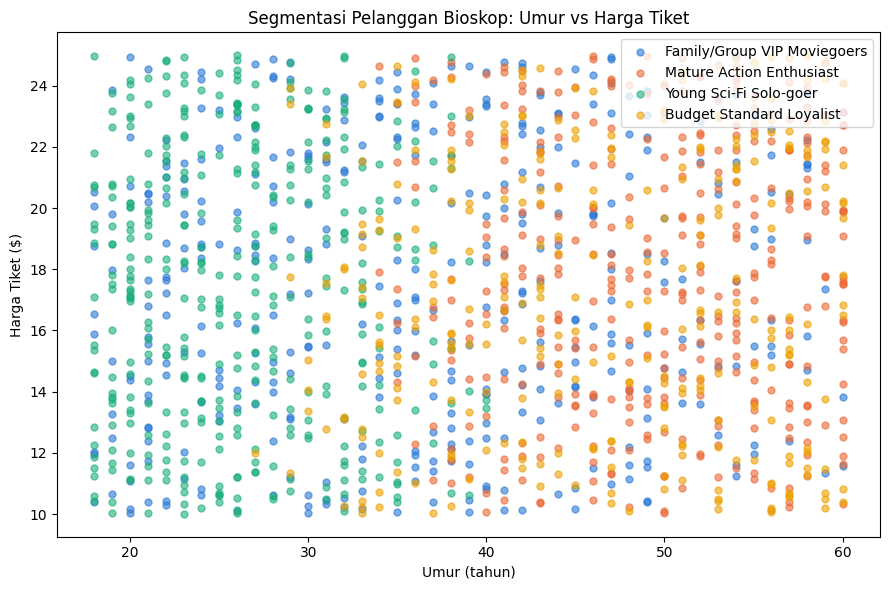

In [ ]:
# -----------------------------------------------------
# STEP 8 - Visualisasi Hasil Clustering
# -----------------------------------------------------

plt.figure(figsize=(9, 6))
colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']

for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    plt.scatter(
        sub['Age'], sub['Ticket_Price'],
        label=persona_map[c], alpha=0.6, color=colors[c], s=25
    )

plt.xlabel('Umur (tahun)')
plt.ylabel('Harga Tiket ($)')
plt.title('Segmentasi Pelanggan Bioskop: Umur vs Harga Tiket')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------
# STEP 9 - Ringkasan Insight per Persona
# -----------------------------------------------------

insight_summary = df.groupby('persona').agg(
    jumlah_pelanggan=('Ticket_ID', 'count'),
    avg_age=('Age', 'mean'),
    avg_price=('Ticket_Price', 'mean'),
    total_revenue=('Ticket_Price', 'sum'),
    retention_rate_pct=('purchase_again_bin', lambda x: round(100 * x.mean(), 1)),
).round(2).sort_values('retention_rate_pct', ascending=False)

print("\nRingkasan per persona (diurutkan dari retensi tertinggi):")
print(insight_summary)


Ringkasan per persona (diurutkan dari retensi tertinggi):
                             jumlah_pelanggan  avg_age  avg_price  \
persona                                                             
Budget Standard Loyalist                  294    46.13      17.01   
Mature Action Enthusiast                  368    49.02      17.71   
Family/Group VIP Moviegoers               394    36.52      17.44   
Young Sci-Fi Solo-goer                    384    26.13      17.31   

                             total_revenue  retention_rate_pct  
persona                                                         
Budget Standard Loyalist           4999.86                53.4  
Mature Action Enthusiast           6516.34                49.7  
Family/Group VIP Moviegoers        6870.50                47.5  
Young Sci-Fi Solo-goer             6646.22                46.9  


In [ ]:
# -----------------------------------------------------
# STEP 10 - Ekspor Hasil Akhir
# -----------------------------------------------------

output_cols = [
    'Ticket_ID', 'Age', 'Ticket_Price', 'Movie_Genre', 'Seat_Type',
    'Number_of_Person', 'group_size', 'attendance_type',
    'Purchase_Again', 'purchase_again_bin', 'seat_rank',
    'cluster', 'persona'
]
df_final = df[output_cols]

output_file = 'cinema_ticket_clustered_final.csv'
df_final.to_csv(output_file, index=False)

print(f"\nFile '{output_file}' berhasil dibuat.")

# Download otomatis ke komputer kamu (khusus Google Colab)
files.download(output_file)


File 'cinema_ticket_clustered_final.csv' berhasil dibuat.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>